<a href="https://colab.research.google.com/github/shristea7/College-Dump/blob/main/AI_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter number of cities: 2
Enter city names:
A
b
Enter number of roads: 3
Enter roads in format: City1 City2 Distance
A b 2
A b 4
A b 8
Enter start city: A
Enter goal city: b

--- RESULTS ---
UCS Path: ['A', 'b'] Cost: 2 Time: 0.00014400482177734375
BFS Path: ['A', 'b'] Time: 0.00010895729064941406
DFS Path: ['A', 'b'] Time: 0.00011658668518066406


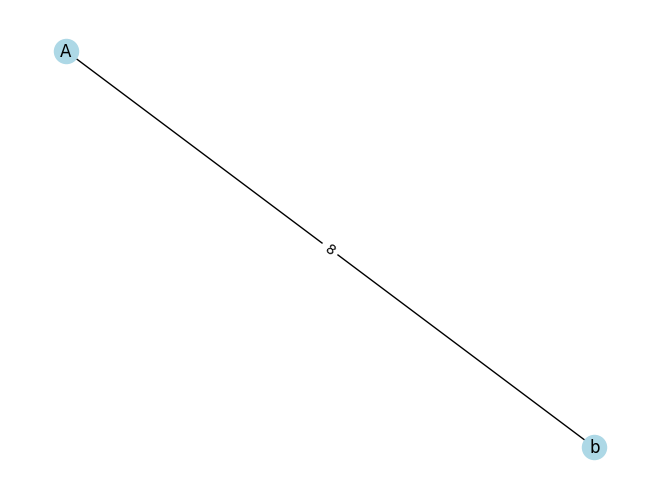

In [ ]:

import heapq
import time
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt


def input_graph():
    graph = {}

    n = int(input("Enter number of cities: "))
    print("Enter city names:")
    cities = [input().strip() for _ in range(n)]

    for city in cities:
        graph[city] = []

    e = int(input("Enter number of roads: "))
    print("Enter roads in format: City1 City2 Distance")

    for _ in range(e):
        u, v, w = input().split()
        w = int(w)
        graph[u].append((v, w))
        graph[v].append((u, w))  # undirected

    return graph



def uniform_cost_search(graph, start, goal):
    pq = []
    heapq.heappush(pq, (0, start, [start]))
    visited = set()

    while pq:
        cost, node, path = heapq.heappop(pq)

        if node in visited:
            continue
        visited.add(node)

        if node == goal:


            return path, cost

        for neighbor, weight in graph[node]:
            if neighbor not in visited:
                heapq.heappush(pq, (cost + weight, neighbor, path + [neighbor]))

    return None, float('inf')


def bfs(graph, start, goal):
    queue = deque([(start, [start])])
    visited = set([start])

    while queue:
        node, path = queue.popleft()
        if node == goal:
            return path

        for neighbor, _ in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    return None



def dfs(graph, start, goal):
    stack = [(start, [start])]
    visited = set([start])

    while stack:
        node, path = stack.pop()
        if node == goal:
            return path

        for neighbor, _ in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                stack.append((neighbor, path + [neighbor]))
    return None



def visualize_graph(graph):
    G = nx.Graph()
    for node in graph:
        for neighbor, weight in graph[node]:
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='lightblue')
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.show()



graph = input_graph()

start_city = input("Enter start city: ")
goal_city = input("Enter goal city: ")

start = time.time()


ucs_path, ucs_cost = uniform_cost_search(graph, start_city, goal_city)
ucs_time = time.time() - start

start = time.time()
bfs_path = bfs(graph, start_city, goal_city)
bfs_time = time.time() - start

start = time.time()
dfs_path = dfs(graph, start_city, goal_city)
dfs_time = time.time() - start

print("\n--- RESULTS ---")
print("UCS Path:", ucs_path, "Cost:", ucs_cost, "Time:", ucs_time)
print("BFS Path:", bfs_path, "Time:", bfs_time)
print("DFS Path:", dfs_path, "Time:", dfs_time)

visualize_graph(graph)
